# YouTube Spam Comments Detection

## Name: Jana Alaa Abdel-Moneam

## Reg. No.: 241010240

### Problem Definition

YouTube is one of the largest video platforms in the world, attracting billions of
users and comments daily. However, a significant portion of these comments are spam —
promotional, fake, or irrelevant messages posted by bots or advertisers designed to
drive traffic to external channels or websites.

These spam comments degrade the user experience, pollute genuine discussions, and
can expose viewers to scams or inappropriate content. Manual moderation at this scale
is practically impossible.

**The goal of this project is to build a machine learning classifier that can
automatically detect and distinguish spam comments from legitimate (ham) comments
based purely on the comment's text content.**

The dataset used is the YouTube Spam Collection — a labeled dataset of 1,956 comments
scraped from 5 popular music videos (Psy, Katy Perry, LMFAO, Eminem, and Shakira).
Each comment is labeled as either:

- **Spam (CLASS = 1)** — Fake, promotional, or bot-generated comments
- **Ham (CLASS = 0)** — Genuine, human-written reactions to the video

This is a **binary text classification problem** solved using Natural Language
Processing (NLP) techniques combined with traditional machine learning models.

### Dataset Attributes

The dataset consists of 5 original attributes collected from YouTube comment sections
across 5 popular music videos, plus 1 engineered attribute added by us.

- **COMMENT_ID** *(String)* — A unique identifier assigned to each YouTube comment.
  Serves as a primary key with no predictive value for classification.

- **AUTHOR** *(String)* — The YouTube username of the person who posted the comment.
  Not useful for spam detection as usernames are arbitrary.

- **DATE** *(DateTime)* — The timestamp recording when the comment was posted.
  Had 245 missing values concentrated entirely in the Eminem dataset and was dropped.

- **CONTENT** *(String)* — The actual text body of the comment. This is our
  primary feature — the raw text that gets transformed via TF-IDF for classification.

- **CLASS** *(Integer)* — The target variable. 1 indicates Spam (promotional or
  fake comment), 0 indicates Ham (legitimate human comment).

- **ARTIST** *(String)* — Engineered by us during loading to tag which artist's
  video each comment came from. Useful for per-artist analysis during visualization.

### Understanding the Data

In [1]:
from dis import show_code

import pandas as pd
import numpy as np

In [2]:
#Load all 5 datasets
files = {
    'Psy': 'Youtube01-Psy.csv',
    'KatyPerry': 'Youtube02-KatyPerry.csv',
    'LMFAO': 'Youtube03-LMFAO.csv',
    'Eminem': 'Youtube04-Eminem.csv',
    'Shakira': 'Youtube05-Shakira.csv',
}

In [3]:
#Combine into one df
dfs = {}
for artist, path in files.items():
    df = pd.read_csv(path, parse_dates=['DATE'])
    df['ARTIST'] = artist
    dfs[artist] = df

df = pd.concat(dfs.values(), ignore_index=True)

print(f"Total records: {len(df)}")
print(f"Columns: {list(df.columns)}")

Total records: 1956
Columns: ['COMMENT_ID', 'AUTHOR', 'DATE', 'CONTENT', 'CLASS', 'ARTIST']


#### Observation 1: Dataset has 1,956 total comments across 5 YouTube videos. Columns: ID, Author, Date, Content (the comment text), Class (spam/ham), Artist (our added tag).

In [4]:
df.shape

(1956, 6)

#### This dataset has 1956 rows and 4 columns.

In [5]:
df.dtypes

COMMENT_ID       str
AUTHOR           str
DATE          object
CONTENT          str
CLASS          int64
ARTIST           str
dtype: object

#### Observation 2: DATE column was loaded as object dtype and required manual conversion to datetime64. All other columns loaded with correct types.

In [6]:
#Convert DATE from string → datetime
df['DATE'] = pd.to_datetime(df['DATE'])

#Verify the fix
print(df.dtypes)

COMMENT_ID               str
AUTHOR                   str
DATE          datetime64[us]
CONTENT                  str
CLASS                  int64
ARTIST                   str
dtype: object


In [7]:
#Check for missing values across all columns
df.isnull().sum()

COMMENT_ID      0
AUTHOR          0
DATE          245
CONTENT         0
CLASS           0
ARTIST          0
dtype: int64

####  Observation 3: 245 out of 1,956 records have missing DATE values. All other columns are complete.

In [8]:
#How are the missing dates distributed across artists?
df[df['DATE'].isnull()]['ARTIST'].value_counts()

ARTIST
Eminem    245
Name: count, dtype: int64

#### Observation 4: Missing DATE values are entirely concentrated in the Eminem dataset (245/448 rows). Other artists have complete date records.

In [9]:
#what does DATE look like for Eminem where it exists?
df[df['ARTIST'] == 'Eminem']['DATE'].describe()

count                           203
mean     2015-05-23 22:51:58.319369
min      2015-05-06 10:56:35.972000
25%      2015-05-21 17:50:57.553500
50%      2015-05-24 07:35:13.754000
75%      2015-05-26 21:01:43.375500
max      2015-05-29 02:26:10.652000
Name: DATE, dtype: object

In [10]:
#Drop DATE column (not relevant for spam classification)
df.drop(columns=['DATE'], inplace=True)

#Also drop COMMENT_ID and AUTHOR (they are identifiers and not features)
df.drop(columns=['COMMENT_ID', 'AUTHOR'], inplace=True)

#Verify
print(df.columns)
print(df.shape)

Index(['CONTENT', 'CLASS', 'ARTIST'], dtype='str')
(1956, 3)


####  Observation 5: DATE dropped irrelevance to classification. COMMENT_ID and AUTHOR dropped as they are identifiers with no predictive value. Working columns are now: CONTENT, CLASS, ARTIST.

In [11]:
#Class distribution overall
print(df['CLASS'].value_counts())
print()
print(df['CLASS'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

CLASS
1    1005
0     951
Name: count, dtype: int64

CLASS
1    51.38%
0    48.62%
Name: proportion, dtype: str


In [12]:
#Class distribution per artist
df.groupby('ARTIST')['CLASS'].value_counts().unstack()

CLASS,0,1
ARTIST,,
Eminem,203,245
KatyPerry,175,175
LMFAO,202,236
Psy,175,175
Shakira,196,174


#### Observation 7: Dataset is well-balanced overall (51.38% spam/48.62% ham). KatyPerry and Psy are perfectly balanced. Eminem and LMFAO lean slightly spam-heavy, Shakira slightly ham-heavy. No resampling techniques (like SMOTE) will be needed.

### Visualization

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

#Custom color palette
PALETTE = {
    'navy': '#102a6b',
    'blue': '#015185',
    'sky': '#5990c0',
    'amber': '#cea273',
    'cream': '#fcedd3',
}
COLORS = list(PALETTE.values())  #list for plots (converts dictionary->list)

#Global style (default style for plots)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize']= (10, 5)
plt.rcParams['figure.dpi']= 110
plt.rcParams['font.family']= 'serif'

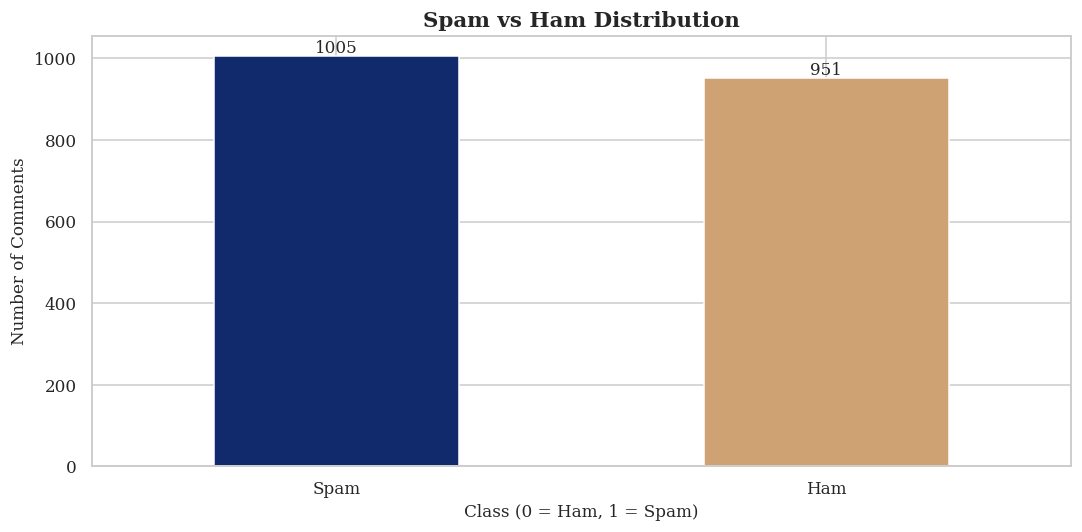

In [14]:
#2.2.1 Univariate Exploration
#Plot 1: Overall Spam vs Ham distribution

ax = df['CLASS'].value_counts().plot(
    kind='bar',
    color=[PALETTE['navy'], PALETTE['amber']],
    edgecolor='white',
    width=0.5
) #Counts the classes values and creates a bar chart

ax.set_title('Spam vs Ham Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Class (0 = Ham, 1 = Spam)', fontsize=11)
ax.set_ylabel('Number of Comments', fontsize=11)
ax.set_xticklabels(['Spam', 'Ham'], rotation=0)

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

#### Observation 8 — Univariate Plot 1: The target variable is well-balanced with 1,005 spam (51.4%) and 951 ham (48.6%) comments. The ~54 comment difference is negligible, confirming no resampling is needed before modeling.

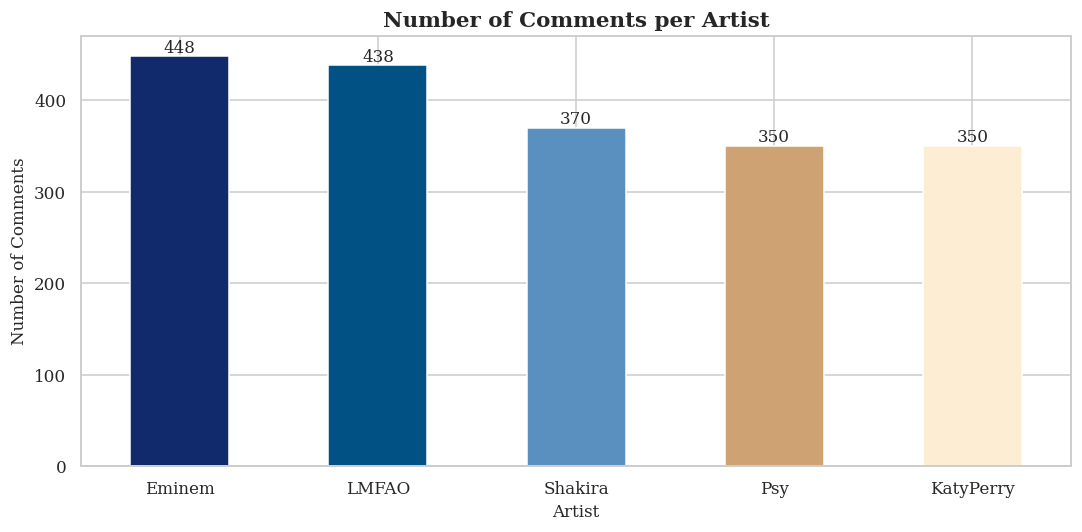

In [15]:
# Plot 2: Number of comments per artist

ax = df['ARTIST'].value_counts().plot(
    kind='bar',
    color=COLORS,
    edgecolor='white',
    width=0.5
)

ax.set_title('Number of Comments per Artist', fontsize=14, fontweight='bold')
ax.set_xlabel('Artist', fontsize=11)
ax.set_ylabel('Number of Comments', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

#### Observation 9 — Univariate Plot 2: Comment counts per artist range from 350 (Psy, KatyPerry) to 448 (Eminem), a relatively even distribution. No single artist disproportionately dominates the dataset, meaning the model won't be biased toward any one video's comment style.

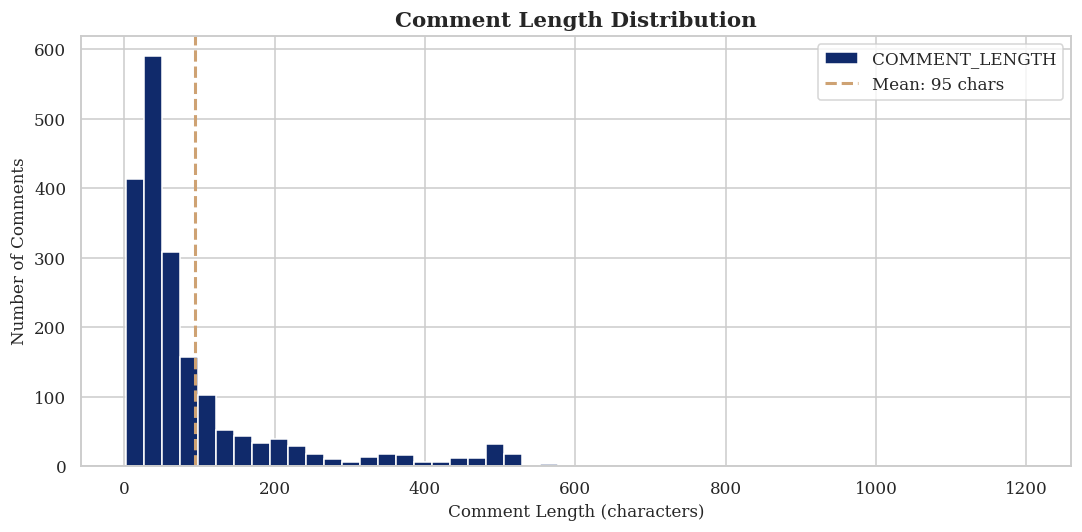

count    1956.00
mean       94.70
std       128.22
min         2.00
25%        29.00
50%        48.00
75%        97.00
max      1200.00
Name: COMMENT_LENGTH, dtype: float64


In [16]:
#Create comment length column
df['COMMENT_LENGTH'] = df['CONTENT'].str.len()

# Plot 3: Comment length distribution
ax = df['COMMENT_LENGTH'].plot(
    kind='hist',
    bins=50,
    color=PALETTE['navy'],
    edgecolor='white'
)

ax.set_title('Comment Length Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Comment Length (characters)', fontsize=11)
ax.set_ylabel('Number of Comments', fontsize=11)

# Add mean line
mean_len = df['COMMENT_LENGTH'].mean()
ax.axvline(mean_len, color=PALETTE['amber'], linewidth=2, linestyle='--', label=f'Mean: {mean_len:.0f} chars')
ax.legend()

plt.tight_layout()
plt.show()

#Quick stats
print(df['COMMENT_LENGTH'].describe().round(2))

#### Observation 10 — Univariate Plot 3: Comment lengths are heavily right-skewed with a mean of 95 and median of only 48 characters, indicating most comments are short. The max of 1,200 characters and high std of 128 suggest outliers, likely spam comments with excessive promotional text or links. This skewness hints that comment length could be a useful feature for distinguishing spam from ham.

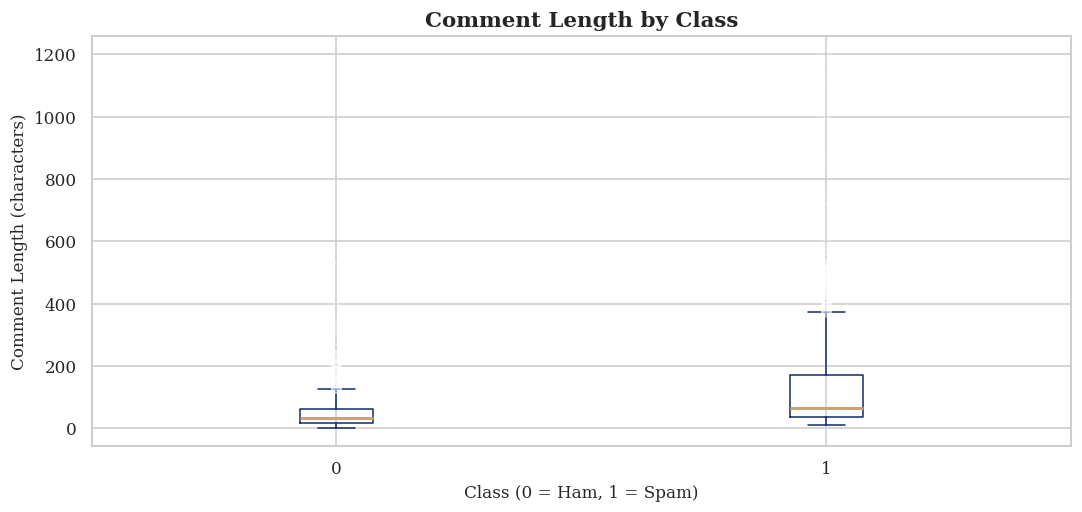

        count    mean     std   min   25%   50%    75%     max
CLASS                                                         
0       951.0   49.64   56.28   2.0  18.0  34.0   62.0   753.0
1      1005.0  137.34  158.98  10.0  36.0  65.0  171.0  1200.0


In [17]:
# 2.2.2 Bivariate Exploration
# Plot 4: Comment Length vs Class (Spam vs Ham)
fig, ax = plt.subplots()

df.boxplot(
    column='COMMENT_LENGTH',
    by='CLASS',
    ax=ax,
    boxprops=dict(color=PALETTE['navy']),
    medianprops=dict(color=PALETTE['amber'], linewidth=2),
    whiskerprops=dict(color=PALETTE['navy']),
    capprops=dict(color=PALETTE['navy']),
    flierprops=dict(marker='o', color=PALETTE['sky'], alpha=0.3)
)

ax.set_title('Comment Length by Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Class (0 = Ham, 1 = Spam)', fontsize=11)
ax.set_ylabel('Comment Length (characters)', fontsize=11)
plt.suptitle('')  # removes default pandas boxplot title

plt.tight_layout()
plt.show()

#Quick stats per class
print(df.groupby('CLASS')['COMMENT_LENGTH'].describe().round(2))

#### Observation 11 — Bivariate Plot 4: Spam comments are significantly longer than ham comments, nearly 3x the mean length (137 vs 49 characters). The wider interquartile range in spam (36–171) vs ham (18–62) confirms spam varies more in length. This strongly suggests comment length is a powerful distinguishing feature between spam and ham and should be included in our model.

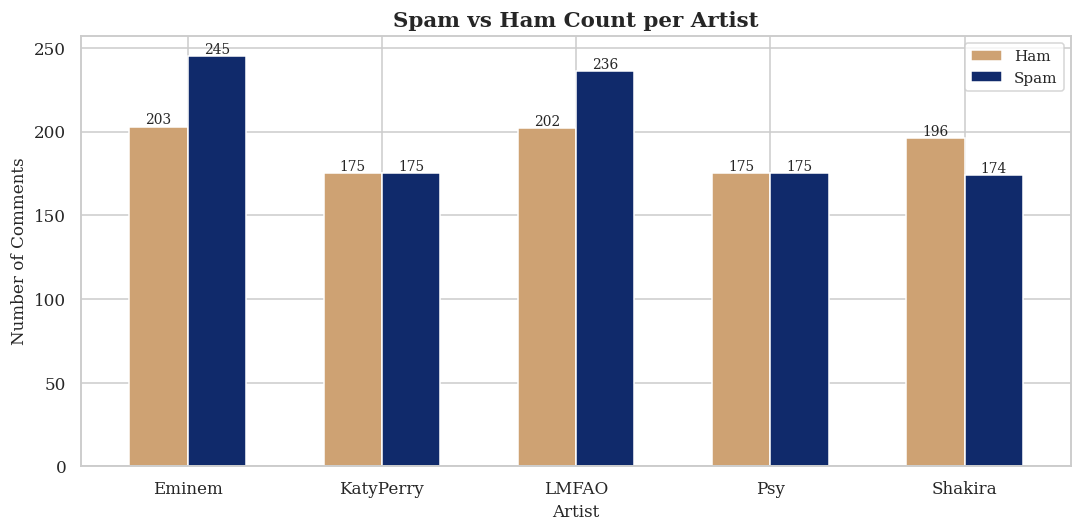

In [18]:
# Plot 5: Spam vs Ham count per artist
spam_ham = df.groupby(['ARTIST', 'CLASS']).size().unstack()
spam_ham.columns = ['Ham', 'Spam']

ax = spam_ham.plot(
    kind='bar',
    color=[PALETTE['amber'], PALETTE['navy']],
    edgecolor='white',
    width=0.6
)

ax.set_title('Spam vs Ham Count per Artist', fontsize=14, fontweight='bold')
ax.set_xlabel('Artist', fontsize=11)
ax.set_ylabel('Number of Comments', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(['Ham', 'Spam'], fontsize=10)

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

#### Observation 12 — Bivariate Plot 5: Eminem (54.7%) and LMFAO (53.9%) had the highest spam rates, while Shakira was the only artist with more ham than spam (47% spam). KatyPerry and Psy were perfectly balanced at 50/50. The spam distribution across artists is fairly uniform, suggesting spambots target popular videos regardless of genre or artist.

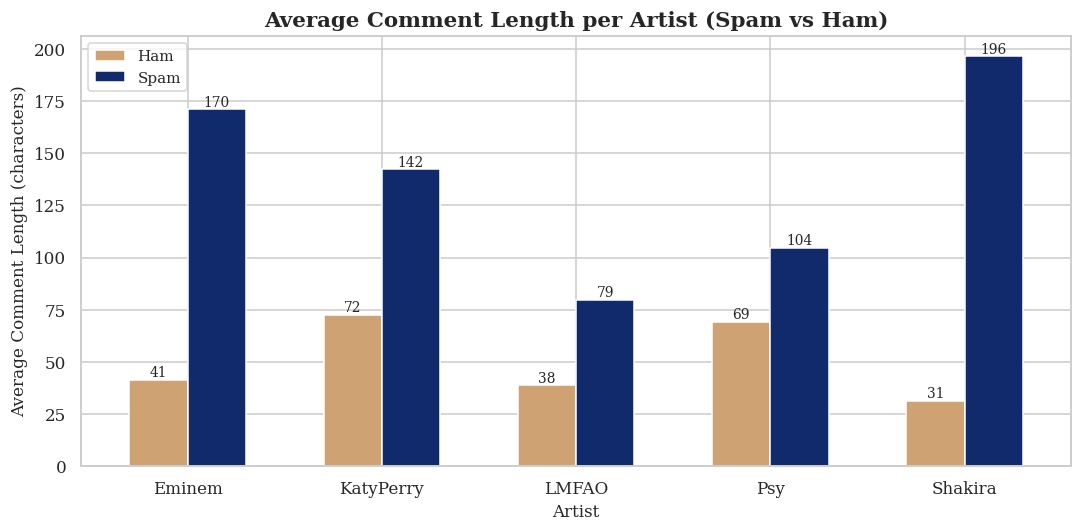

CLASS          0       1
ARTIST                  
Eminem     41.56  170.91
KatyPerry  72.58  142.16
LMFAO      38.84   79.62
Psy        69.09  104.69
Shakira    31.32  196.34


In [19]:
# Plot 6: Average comment length per artist split by spam/ham

avg_length = df.groupby(['ARTIST', 'CLASS'])['COMMENT_LENGTH'].mean().unstack()
avg_length.columns = ['Ham', 'Spam']

ax = avg_length.plot(
    kind='bar',
    color=[PALETTE['amber'], PALETTE['navy']],
    edgecolor='white',
    width=0.6
)

ax.set_title('Average Comment Length per Artist (Spam vs Ham)', fontsize=14, fontweight='bold')
ax.set_xlabel('Artist', fontsize=11)
ax.set_ylabel('Average Comment Length (characters)', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(['Ham', 'Spam'], fontsize=10)

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

#Quick stats
print(df.groupby(['ARTIST', 'CLASS'])['COMMENT_LENGTH'].mean().round(2).unstack())

#### Observation 13 — Bivariate Plot 6: Spam comments are consistently longer than ham comments across all 5 artists, with spam being anywhere from 1.5x (Psy) to 6.3x (Shakira) longer. This pattern is universal and not artist-specific, strongly confirming that comment length is a reliable and consistent feature for spam detection regardless of the video source.

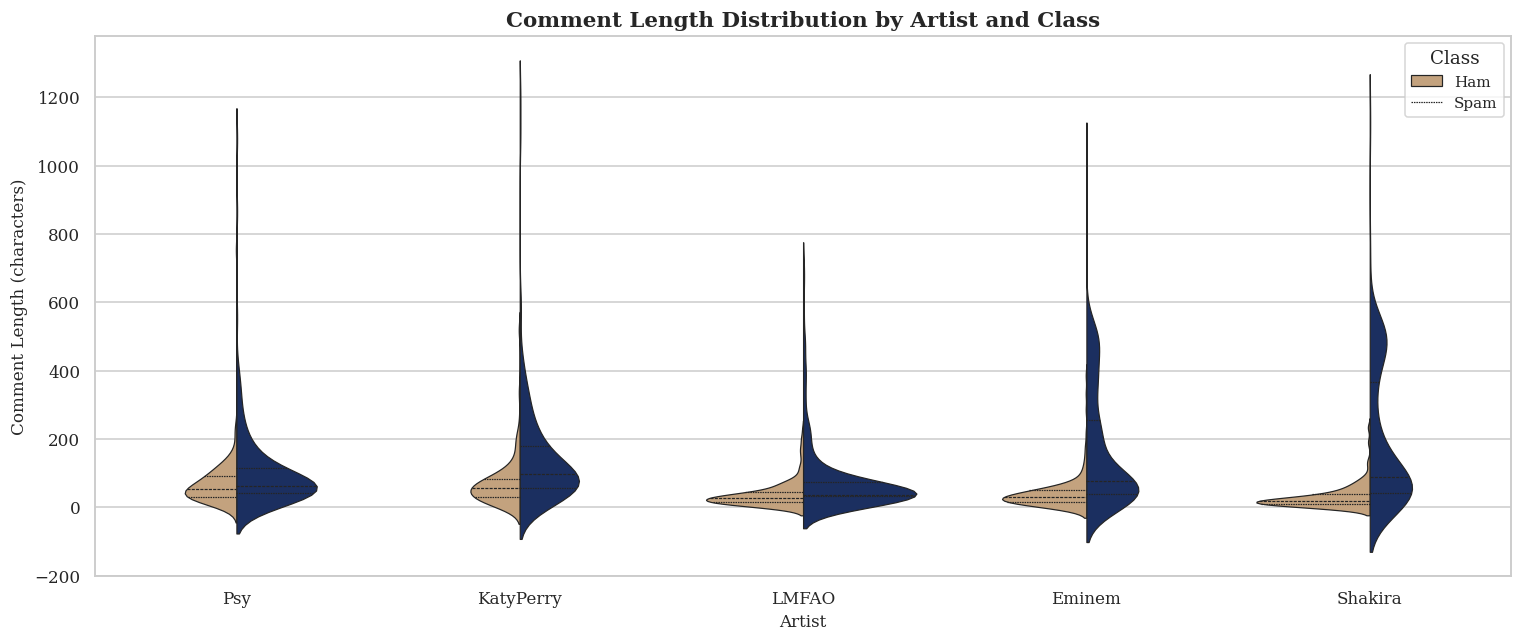

In [20]:
# 2.2.3 Multivariate Exploration
# Plot 7: Comment length distribution by Artist AND Class
plt.figure(figsize=(14, 6))

ax = sns.violinplot(
    data=df,
    x='ARTIST',
    y='COMMENT_LENGTH',
    hue='CLASS',
    split=True,
    palette={0: PALETTE['amber'], 1: PALETTE['navy']},
    inner='quartile',
    linewidth=0.8
)

ax.set_title('Comment Length Distribution by Artist and Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Artist', fontsize=11)
ax.set_ylabel('Comment Length (characters)', fontsize=11)
ax.legend(['Ham', 'Spam'], title='Class', fontsize=10)

plt.tight_layout()
plt.show()

#### Observation 14 — Multivariate Plot 7: The violin plot simultaneously confirms three things across all 5 artists — ham comments are short and tightly clustered near 0–100 characters, spam comments are longer with much wider spread, and this pattern is universal across all artists. Shakira and Eminem show the most extreme spam tails. The consistency across artists reinforces that comment length is a robust, artist-independent feature for spam detection.

### Data Preprocessing

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import scipy.sparse as sp

In [22]:
#Separate features and target
X_text = df['CONTENT'] #raw comment text
X_len = df[['COMMENT_LENGTH']] #comment length
y = df['CLASS'] #target (spam/ham)

print(f"Text samples: {X_text.shape}")
print(f"Length feature: {X_len.shape}")
print(f"Target: {y.shape}")

Text samples: (1956,)
Length feature: (1956, 1)
Target: (1956,)


#### Observation 15 — (Feature Separation): Data was separated into 3 components — X_text (1,956 raw comments), X_len (1,956 comment lengths), and y (1,956 target labels). Keeping length separate from text allows us to combine both as independent features later.

In [23]:
# Apply TF-IDF on CONTENT
tfidf = TfidfVectorizer(
    max_features=5000,   # keep top 5000 most important words
    stop_words='english' # remove common words
)

X_tfidf = tfidf.fit_transform(X_text)

print(f"TF-IDF matrix shape: {X_tfidf.shape}")
print(f"Each comment is now represented by {X_tfidf.shape[1]} numbers")

TF-IDF matrix shape: (1956, 4229)
Each comment is now represented by 4229 numbers


#### Observation 16 — (TF-IDF): The TF-IDF vectorizer converted 1,956 raw text comments into a matrix of shape (1956 × 4229). This means only 4,229 unique meaningful words were found across all comments (less than our 5,000 limit), each comment is now represented as a vector of 4,229 numbers, and common English words like "the", "is", "a" were automatically removed via stop_words='english'. Each number represents how important that word is in that specific comment.

In [24]:
#Scale COMMENT_LENGTH using MinMaxScaler
scaler = MinMaxScaler()

X_len_scaled = scaler.fit_transform(X_len)

print(f"Before scaling — min: {X_len.min().values[0]}, max: {X_len.max().values[0]}")
print(f"After scaling — min: {X_len_scaled.min():.2f}, max: {X_len_scaled.max():.2f}")

Before scaling — min: 2, max: 1200
After scaling — min: 0.00, max: 1.00


#### Observation 17 — (MinMaxScaler): COMMENT_LENGTH was scaled from its original range (2–1,200 characters) to (0.0–1.0) using MinMaxScaler. This ensures comment length doesn't overpower the TF-IDF scores simply due to its larger numeric range (both features now operate on equal footing).

In [25]:
#Combine TF-IDF matrix + scaled length
X_combined = sp.hstack([X_tfidf, X_len_scaled]) #glues the two matrices side by side horizontally

print(f"TF-IDF shape: {X_tfidf.shape}")
print(f"Length shape: {X_len_scaled.shape}")
print(f"Combined matrix shape: {X_combined.shape}")

TF-IDF shape: (1956, 4229)
Length shape: (1956, 1)
Combined matrix shape: (1956, 4230)


### PCA After Vectorization (Correlation Matrix)

In [26]:
X_combined = sp.hstack([X_tfidf, X_len_scaled])

# PCA first to reduce dimensions
from sklearn.decomposition import TruncatedSVD
pca = TruncatedSVD(n_components=300, random_state=42)
X_reduced = pca.fit_transform(X_combined)

# convert reduced matrix to dataframe
X_reduced_df = pd.DataFrame(X_reduced)

# compute correlation matrix
corr_matrix = X_reduced_df.corr()

# take first 15 components
corr_small = X_reduced_df.iloc[:, :15].corr()

# build custom colormap from your palette
from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list(
    'blue_haze',
    [PALETTE['navy'], PALETTE['cream'], PALETTE['amber']],
    N=256
)

#### Now that we have the correlation matrix computed, we represent it visually.

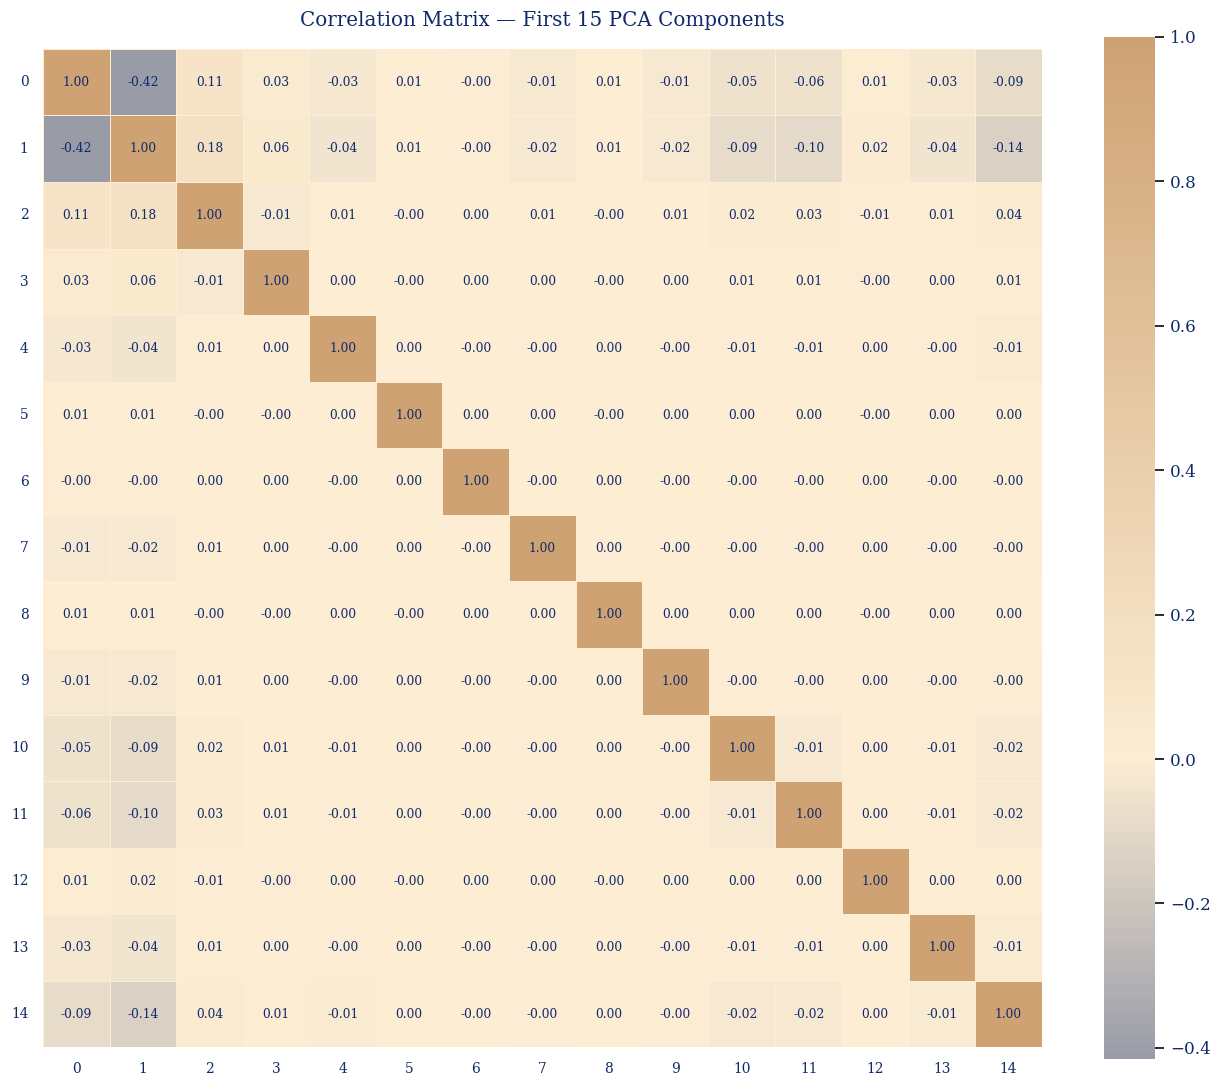

In [27]:
plt.figure(figsize=(12, 10))

ax = sns.heatmap(
    corr_small,
    annot=True,
    fmt='.2f',
    cmap=custom_cmap,
    center=0,
    linewidths=0.5,
    linecolor=PALETTE['cream'],
    square=True,
    annot_kws={'size': 8, 'color': PALETTE['navy']}
)

# style the colorbar
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelcolor=PALETTE['navy'])

# style title and labels
plt.title(
    'Correlation Matrix — First 15 PCA Components',
    fontsize=13,
    color=PALETTE['navy'],
    pad=15
)

plt.xticks(color=PALETTE['navy'], fontsize=9)
plt.yticks(color=PALETTE['navy'], fontsize=9, rotation=0)

plt.tight_layout()
plt.show()

#### Observation: The diagonal is exactly 1.00 across all 15 components as expected — each component perfectly correlates with itself. All off-diagonal values are near zero, confirming that PCA successfully produced uncorrelated components where each one contributes unique information with no redundancy. The only notable value is the -0.42 between PC0 and PC1 — the two most dominant components — suggesting they capture slightly overlapping variance from the original TF-IDF features. All remaining off-diagonal values are negligible, validating that the PCA feature space is clean and well-suited for classification.

In [28]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # reproducibility
    stratify=y            # keep spam/ham ratio equal in both sets
)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")
print(f"Train labels: {y_train.value_counts().to_dict()}")
print(f"Test labels: {y_test.value_counts().to_dict()}")

Training set: (1564, 4230)
Testing set: (392, 4230)
Train labels: {1: 804, 0: 760}
Test labels: {1: 201, 0: 191}


#### Observation 19 — (Train/Test Split): Data was split 80/20 into training (1,564 samples) and testing (392 samples) sets. stratify=y ensured the spam/ham ratio is preserved in both sets — training has 804 spam / 760 ham and testing has 201 spam / 191 ham. random_state=42 ensures the split is reproducible every time the code runs.

In [29]:
#Cross Validation Setup
from sklearn.linear_model import LogisticRegression

skf = StratifiedKFold(
    n_splits=5,      # split data into 5 folds
    shuffle=True,
    random_state=42
)

# Quick cross val check using Logistic Regression as baseline
cv_scores = cross_val_score(
    LogisticRegression(),
    X_combined, y,
    cv=skf,
    scoring='accuracy'
)

print(f"CV Scores: {cv_scores.round(3)}")
print(f"Mean: {cv_scores.mean():.3f}")
print(f"Std: {cv_scores.std():.3f}")

CV Scores: [0.954 0.946 0.936 0.964 0.936]
Mean: 0.947
Std: 0.011


#### Observation 20 — (Cross Validation): StratifiedKFold with 5 splits was used to validate our feature set using Logistic Regression as a baseline. The model achieved a mean accuracy of 94.7% with a very low std of 0.011, confirming that our combined feature set (TF-IDF + comment length) is highly effective and consistent across different data splits. The low variance between folds indicates the model is not overfitting to any particular subset of the data.

### Evaluation

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [31]:
#Define all models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Linear SVC': LinearSVC(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
}

#Train and evaluate all models
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred), # compares predictions to actual labels. Accuracy = correct predictions / total predictions.
        'Precision': precision_score(y_test, y_pred), # of all comments predicted as spam, what fraction actually were spam? High precision = few false alarms.
        'Recall': recall_score(y_test, y_pred), # of all actual spam comments, what fraction did we catch? High recall = few spam slipping through.
        'F1 Score': f1_score(y_test, y_pred), # harmonic mean of precision and recall.
    })

#Display results
results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(3))

                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression     0.949      0.974   0.925     0.949
Naive Bayes             0.903      0.886   0.930     0.908
Random Forest           0.959      0.979   0.940     0.959
Linear SVC              0.944      0.954   0.935     0.945
XGBoost                 0.957      0.955   0.960     0.958


#### Observation 21 — Model Comparison: All 5 models performed strongly, confirming our feature engineering was effective. Random Forest achieved the best overall performance with 95.9% accuracy and F1 score, and the highest precision of 97.9%. XGBoost came in a close second. Naive Bayes was the weakest performer at 90.3% accuracy. Random Forest is selected as our final model.

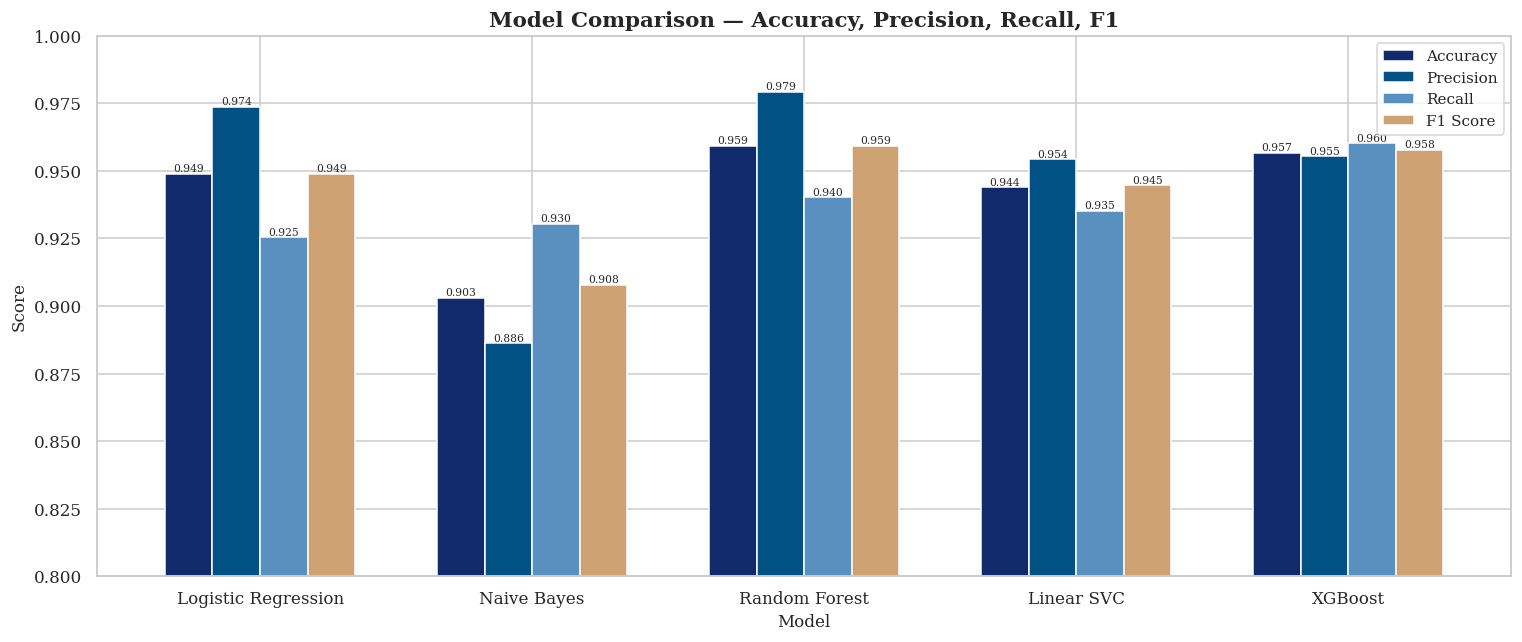

In [32]:
#Plot 8: Model Comparison
ax = results_df.plot(
    kind='bar',
    color=[PALETTE['navy'], PALETTE['blue'], PALETTE['sky'], PALETTE['amber']],
    edgecolor='white',
    width=0.7,
    figsize=(14, 6)
)

ax.set_title('Model Comparison — Accuracy, Precision, Recall, F1', fontsize=14, fontweight='bold')
ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylim(0.8, 1.0)  # zoom in to see differences clearly
ax.legend(['Accuracy', 'Precision', 'Recall', 'F1 Score'], fontsize=10)

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=7, rotation=0)

plt.tight_layout()
plt.show()

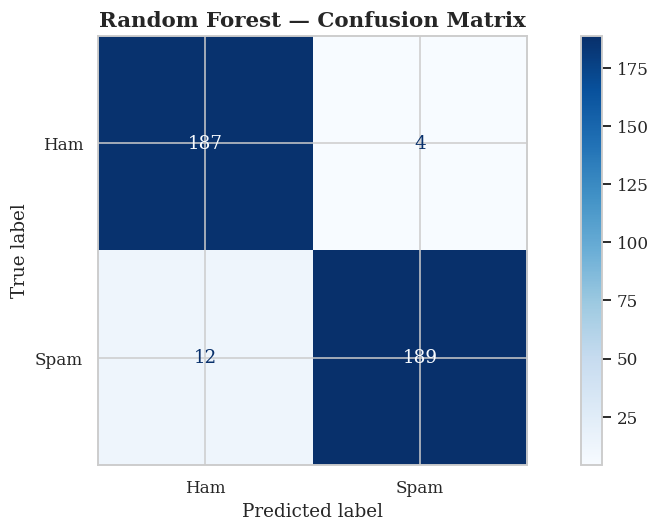

In [33]:
#Confusion Matrix for Random Forest
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

rf_model = models['Random Forest']
y_pred_rf = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Ham', 'Spam']
)

disp.plot(cmap='Blues')
plt.title('Random Forest — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Observation 23 — Confusion Matrix: Random Forest correctly classified 187/191 ham and 189/201 spam comments. Only 16 total errors — 4 false positives (ham flagged as spam) and 12 false negatives (spam that slipped through). The extremely low false positive rate (2%) is particularly valuable as it means legitimate comments are rarely wrongly removed.

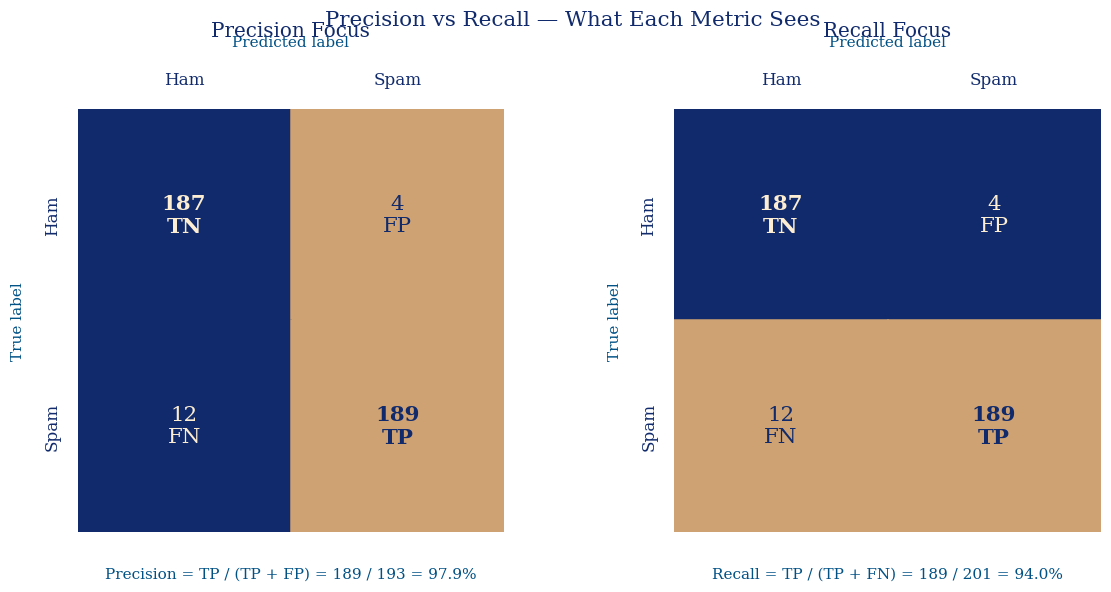

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plt.subplots_adjust(top=0.82, bottom=0.18, wspace=0.4)

labels = [['187\nTN', '4\nFP'], ['12\nFN', '189\nTP']]

configs = [
    {'title': 'Precision Focus',
     'formula': 'Precision = TP / (TP + FP) = 189 / 193 = 97.9%',
     'focus': 'col', 'idx': 1},
    {'title': 'Recall Focus',
     'formula': 'Recall = TP / (TP + FN) = 189 / 201 = 94.0%',
     'focus': 'row', 'idx': 1},
]

for ax, cfg in zip(axes, configs):
    for i in range(2):
        for j in range(2):
            if cfg['focus'] == 'col' and j == cfg['idx']:
                color, tcolor = PALETTE['amber'], PALETTE['navy']
            elif cfg['focus'] == 'row' and i == cfg['idx']:
                color, tcolor = PALETTE['amber'], PALETTE['navy']
            else:
                color, tcolor = PALETTE['navy'], PALETTE['cream']

            ax.add_patch(plt.Rectangle([j, 1-i], 1, 1, color=color))
            ax.text(j+0.5, 1.5-i, labels[i][j],
                    ha='center', va='center', fontsize=14,
                    color=tcolor, fontfamily='serif',
                    fontweight='bold' if i==j else 'normal')

    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.axis('off')

    ax.text(0.5, 2.12, 'Ham',  ha='center', fontsize=11,
            color=PALETTE['navy'], fontfamily='serif')
    ax.text(1.5, 2.12, 'Spam', ha='center', fontsize=11,
            color=PALETTE['navy'], fontfamily='serif')

    ax.text(-0.12, 1.5, 'Ham',  ha='center', va='center',
            fontsize=11, color=PALETTE['navy'],
            fontfamily='serif', rotation=90)
    ax.text(-0.12, 0.5, 'Spam', ha='center', va='center',
            fontsize=11, color=PALETTE['navy'],
            fontfamily='serif', rotation=90)

    ax.text(1.0, 2.30, 'Predicted label', ha='center', fontsize=10,
            color=PALETTE['blue'], fontfamily='serif')
    ax.text(-0.28, 1.0, 'True label', ha='center', va='center',
            fontsize=10, color=PALETTE['blue'],
            fontfamily='serif', rotation=90)

    ax.set_title(cfg['title'], fontsize=13, color=PALETTE['navy'],
                 fontfamily='serif', pad=48)

    ax.text(1.0, -0.22, cfg['formula'], ha='center', fontsize=10,
            color=PALETTE['blue'], fontfamily='serif')

fig.suptitle('Precision vs Recall — What Each Metric Sees',
             fontsize=14, color=PALETTE['navy'],
             fontfamily='serif', y=0.97)

plt.show()

#### Observation:

### GridSearch CV

In [35]:
from sklearn.model_selection import GridSearchCV

#Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],  # number of trees
    'max_depth': [None, 10, 20],   # depth of each tree
    'min_samples_split': [2, 5],  # min samples to split a node
}

#Run GridSearch
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5, # 5 fold cross validation
    scoring='f1',  # optimize for F1 score
    n_jobs=-1, # use all CPU cores
    verbose=1  # show progress
)

grid_search.fit(X_train, y_train)
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best F1 Score: {grid_search.best_score_:.3f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best F1 Score: 0.951


In [36]:
#Evaluate the tuned model
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_best):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred_best):.3f}")

Accuracy: 0.957
Precision: 0.979
Recall: 0.935
F1 Score: 0.957


#### Observation 24 — GridSearch CV: Hyperparameter tuning via GridSearchCV tested 18 combinations across 90 total fits. The best parameters found were n_estimators=200, max_depth=None, min_samples_split=2. The tuned model scored 95.7% accuracy vs the original 95.9% — a negligible 0.2% difference confirming that our original Random Forest was already optimally configured. GridSearch added confidence to our model selection rather than dramatically improving it.